# EDA українського датасету для задачі виявлення спаму

Мета цього ноутбука -- виконати початковий аналіз даних, зрозуміти їхню структуру, виявити характерні ознаки спам-повідомлень і підготувати дані до побудови baseline-моделей.

У межах цього ноутбука виконується:
1. завантаження та первинна перевірка датасету;
2. аналіз структури, пропусків і дублікатів;
3. аналіз балансу класів;
4. аналіз довжини повідомлень;
5. аналіз частотних слів;
6. аналіз характерних ознак спаму (посилання, капслок, спецсимволи);
7. поділ на train/test вибірки;
8. формулювання висновків.

In [1]:
import re
from collections import Counter

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Завантаження даних

Використовується датасет `amiadesu/ukrainian-social-spam` з Kaggle. 

In [2]:
dataset_dir = kagglehub.dataset_download("amiadesu/ukrainian-social-spam")
print("Dataset directory:", dataset_dir)

Dataset directory: C:\Users\User\.cache\kagglehub\datasets\amiadesu\ukrainian-social-spam\versions\2


In [3]:
from pathlib import Path

dataset_path = Path(dataset_dir)
csv_files = list(dataset_path.rglob("*.csv"))
print("Found CSV files:", csv_files)

if not csv_files:
    raise FileNotFoundError("CSV-файл не знайдено в директорії датасету.")

csv_path = csv_files[0]
print("Using file:", csv_path)

data = pd.read_csv(csv_path)
data.head()

Found CSV files: [WindowsPath('C:/Users/User/.cache/kagglehub/datasets/amiadesu/ukrainian-social-spam/versions/2/spam.csv')]
Using file: C:\Users\User\.cache\kagglehub\datasets\amiadesu\ukrainian-social-spam\versions\2\spam.csv


,text,spam
0,"__USER__ Це лека, і вона дуже крута, вона наша адміністраторка, я за тебе, тебе представлю",0
1,"У другому турі підтримав Віктора Ющенка, поставивши однією з головних умов підтримки впровадження політичної реформи...",0
2,"🪖 Твоя ідеальна підробітка? Знайдена. Без босів, без дзвінків, без офісу — тільки телефон і вільний час 💀 💵 25 000 г...",1
3,"🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезування“БЕЗ ОБМЕЖЕНЬ” (Київ, метро Нивки) Хочеш працювати у місці, де зміню...",1
4,__USER__ Відміть мене коли зможеш,0


## 2. Первинний огляд структури датасету

На цьому кроці потрібно перевірити:
- розмір датасету;
- назви колонок;
- типи даних;
- приклади записів;
- структуру цільової змінної.

In [4]:
print("Shape:", data.shape)
print("\nColumns:", list(data.columns))
print("\nПерші 5 рядків:")
display(data.head())

Shape: (91386, 2)

Columns: ['text', 'spam']

Перші 5 рядків:


,text,spam
0,"__USER__ Це лека, і вона дуже крута, вона наша адміністраторка, я за тебе, тебе представлю",0
1,"У другому турі підтримав Віктора Ющенка, поставивши однією з головних умов підтримки впровадження політичної реформи...",0
2,"🪖 Твоя ідеальна підробітка? Знайдена. Без босів, без дзвінків, без офісу — тільки телефон і вільний час 💀 💵 25 000 г...",1
3,"🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезування“БЕЗ ОБМЕЖЕНЬ” (Київ, метро Нивки) Хочеш працювати у місці, де зміню...",1
4,__USER__ Відміть мене коли зможеш,0


In [5]:
print("Інформація про датасет:")
data.info()

Інформація про датасет:
<class 'pandas.DataFrame'>
RangeIndex: 91386 entries, 0 to 91385
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    91386 non-null  str  
 1   spam    91386 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.4 MB


In [6]:
print("Кількість унікальних значень у кожній колонці:")
display(data.nunique())

print("\nУнікальні значення цільової змінної 'spam':")
display(data["spam"].value_counts(dropna=False))

Кількість унікальних значень у кожній колонці:


text    91386
spam        2
dtype: int64


Унікальні значення цільової змінної 'spam':


spam
0    65165
1    26221
Name: count, dtype: int64

## 3. Перевірка якості даних: пропуски і дублікати

Для задач текстової класифікації важливо перевірити:
- чи є пропуски в текстах;
- чи є повністю дубльовані записи;
- чи потрібно очищення перед подальшим аналізом.

In [7]:
print("Пропуски по колонках:")
display(data.isnull().sum())

print("\nКількість повних дублікатів:", data.duplicated().sum())

Пропуски по колонках:


text    0
spam    0
dtype: int64


Кількість повних дублікатів: 0


In [8]:
# За потреби можна очистити дані від дублікатів і пропусків.
# Нижче показано базовий варіант, але спершу варто оцінити, чи не втратимо корисні приклади.

clean_data = data.dropna(subset=["text", "spam"]).drop_duplicates().copy()

print("Розмір початкового датасету:", data.shape)
print("Розмір після базового очищення:", clean_data.shape)

Розмір початкового датасету: (91386, 2)
Розмір після базового очищення: (91386, 2)


Якщо дублікати або пропуски є, потрібно вказати:
- скільки саме записів було видалено;
- чому це було зроблено;
- як це може вплинути на якість моделі.

## 4. Аналіз балансу класів

Для задачі фільтрації спаму потрібно зрозуміти, чи є дисбаланс класів. 
Це впливатиме на вибір метрик і, можливо, на налаштування моделей.

In [9]:
class_counts = clean_data["spam"].value_counts().sort_index()
class_share = clean_data["spam"].value_counts(normalize=True).sort_index() * 100

print("Кількість об'єктів у класах:")
display(class_counts)

print("\nЧастка об'єктів у класах, %:")
display(class_share.round(2))

Кількість об'єктів у класах:


spam
0    65165
1    26221
Name: count, dtype: int64


Частка об'єктів у класах, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64

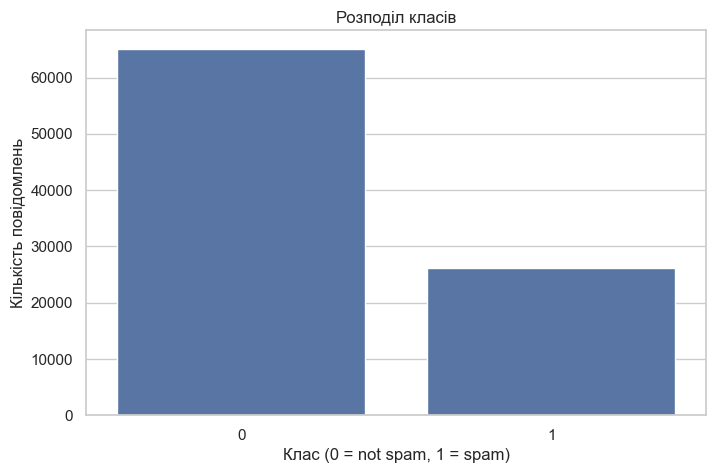

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=clean_data, x="spam")
ax.set_title("Розподіл класів")
ax.set_xlabel("Клас (0 = not spam, 1 = spam)")
ax.set_ylabel("Кількість повідомлень")
plt.show()

Після цього блоку робимо короткий висновок:
- чи є дисбаланс класів;
- чи є він критичним;
- чи потрібно враховувати його під час навчання моделей.

## 5. Аналіз довжини повідомлень

Довжина тексту часто є корисною ознакою: спам-повідомлення можуть бути або значно коротшими, або навпаки містити розширені рекламні формулювання, заклики до дії та посилання.

In [11]:
clean_data["length_chars"] = clean_data["text"].astype(str).str.len()
clean_data["length_words"] = clean_data["text"].astype(str).str.split().apply(len)

display(clean_data[["length_chars", "length_words"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
length_chars,91386.0,154.018690,217.147132,21.0,44.0,80.0,168.0,4056.0
length_words,91386.0,24.566925,34.585820,1.0,8.0,13.0,25.0,833.0


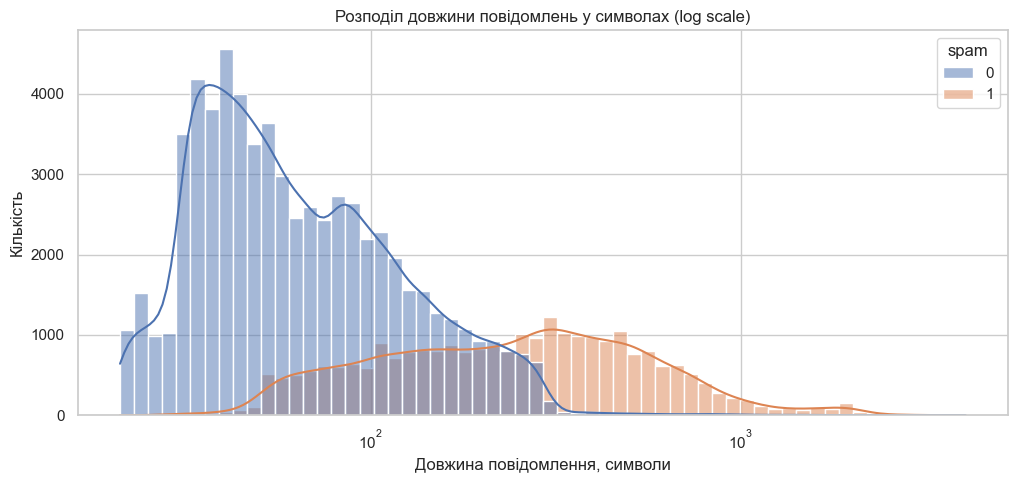

In [12]:
plt.figure(figsize=(12, 5))
sns.histplot(data=clean_data, x="length_chars", hue="spam", bins=60, kde=True, log_scale=True)
plt.title("Розподіл довжини повідомлень у символах (log scale)")
plt.xlabel("Довжина повідомлення, символи")
plt.ylabel("Кількість")
plt.show()

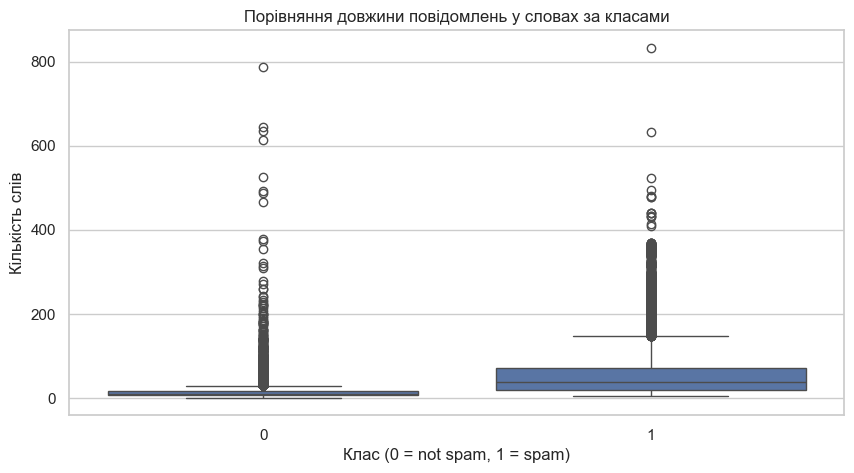

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=clean_data, x="spam", y="length_words")
plt.title("Порівняння довжини повідомлень у словах за класами")
plt.xlabel("Клас (0 = not spam, 1 = spam)")
plt.ylabel("Кількість слів")
plt.show()

In [14]:
length_summary = clean_data.groupby("spam")[["length_chars", "length_words"]].agg(["mean", "median"])
display(length_summary)

length_chars        length_words       
             mean median         mean median
spam                                        
0       81.212537   57.0    12.808885   10.0
1      334.958125  249.0    53.788261   39.0

Тут потрібно пояснити:
- чи відрізняються spam і not spam за довжиною;
- чому на гістограмі використано логарифмічну шкалу;
- чи може довжина тексту бути додатковою ознакою для класифікації.

## 6. Аналіз частотних слів

На цьому кроці варто подивитися, які слова найчастіше зустрічаються:
- у спамі;
- у звичайних повідомленнях.

Це допоможе зрозуміти, чи справді класи відрізняються лексично, а також обґрунтувати подальше використання TF-IDF.

In [15]:
def tokenize_simple(text: str):
    text = str(text).lower()
    return re.findall(r"\b[\w'’\-]+\b", text, flags=re.UNICODE)

spam_tokens = []
ham_tokens = []

for text, label in zip(clean_data["text"], clean_data["spam"]):
    tokens = tokenize_simple(text)
    if label == 1:
        spam_tokens.extend(tokens)
    else:
        ham_tokens.extend(tokens)

spam_counter = Counter(spam_tokens)
ham_counter = Counter(ham_tokens)

top_spam = pd.DataFrame(spam_counter.most_common(20), columns=["word", "count"])
top_ham = pd.DataFrame(ham_counter.most_common(20), columns=["word", "count"])

print("ТОП-20 слів у spam:")
display(top_spam)

print("ТОП-20 слів у not spam:")
display(top_ham)

ТОП-20 слів у spam:


,word,count
0,грн,40092
1,за,25337
2,на,24826
3,__url__,23411
4,в,19135
5,з,16603
6,від,15738
7,та,13352
8,2,10999
9,5,10087


ТОП-20 слів у not spam:


,word,count
0,в,17626
1,__user__,15491
2,на,15014
3,і,14067
4,я,13902
5,не,12661
6,з,10959
7,у,10188
8,та,6891
9,що,6783


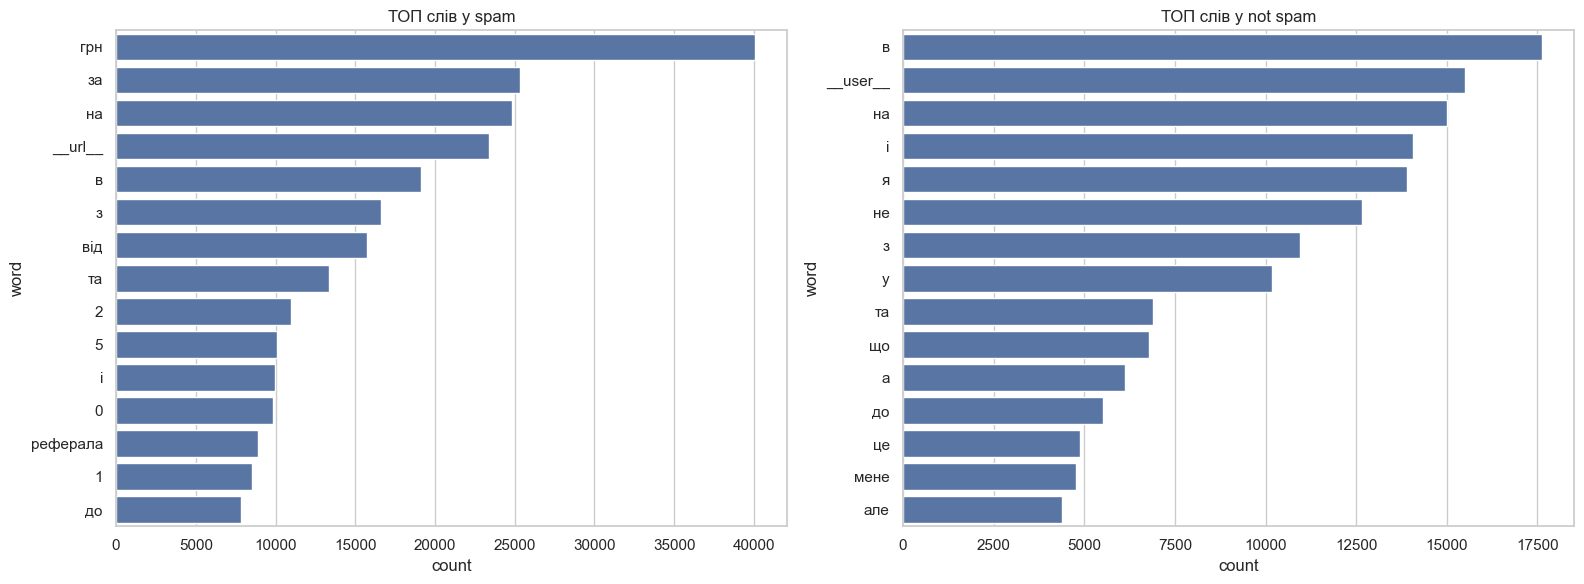

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_spam.head(15), x="count", y="word", ax=axes[0])
axes[0].set_title("ТОП слів у spam")

sns.barplot(data=top_ham.head(15), x="count", y="word", ax=axes[1])
axes[1].set_title("ТОП слів у not spam")

plt.tight_layout()
plt.show()

За бажанням сюди можна додати:
- список стоп-слів для української мови;
- очищення від дуже частих службових слів;
- окремий аналіз біграм або триграм.

Але навіть базовий список частотних слів уже дає корисне розуміння структури текстів.

## 7. Аналіз характерних ознак спаму

Крім самих слів, для спаму часто характерні додаткові ознаки:
- наявність URL;
- велика частка великих літер;
- надлишок спеціальних символів;
- повтори знаків оклику або інших символів.

In [17]:
# clean_data["has_url"] = clean_data["text"].astype(str).str.contains(r"http[s]?://|www\.", regex=True, case=False)
clean_data["has_url"] = clean_data["text"].astype(str).str.contains(r"__URL__", regex=True, case=False)
# будь-які символи поза літерами/цифрами/пробілами, тобто пунктуація, emoji та знаки на кшталт !, ?, ., ,, :, ;, @, #, $, %, &, *, (, ), -, _, =, +
clean_data["has_special_chars"] = clean_data["text"].astype(str).str.contains(r"[^\w\s]", regex=True)

def upper_ratio(text: str) -> float:
    text = str(text)
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    upper_letters = [c for c in letters if c.isupper()]
    return len(upper_letters) / len(letters)

clean_data["upper_ratio"] = clean_data["text"].astype(str).apply(upper_ratio)

feature_summary = clean_data.groupby("spam")[["has_url", "has_special_chars", "upper_ratio"]].mean()
display(feature_summary)

,has_url,has_special_chars,upper_ratio
spam,,,
0,0.001657,0.672416,0.094611
1,0.366767,0.964990,0.193680


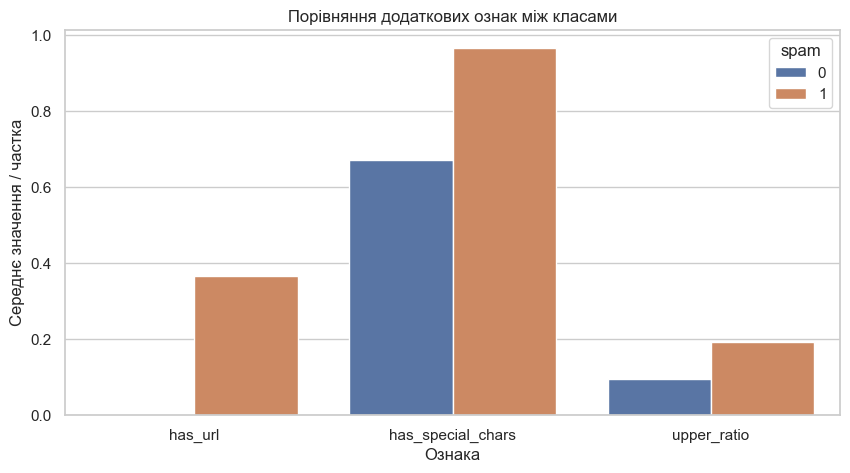

In [18]:
feature_plot = feature_summary.reset_index().melt(id_vars="spam", var_name="feature", value_name="value")

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_plot, x="feature", y="value", hue="spam")
plt.title("Порівняння додаткових ознак між класами")
plt.xlabel("Ознака")
plt.ylabel("Середнє значення / частка")
plt.show()

Після цього блоку варто письмово відповісти:
- чи частіше спам містить посилання;
- чи має спам більшу частку великих літер;
- чи є спецсимволи характерною ознакою спаму.

## 8. Формалізація задачі

На основі проаналізованих даних задачу можна формалізувати як задачу бінарної класифікації:
- вхід: текст повідомлення;
- вихід: клас `spam` або `not spam`.

Для оцінювання моделей доцільно використовувати:
- precision;
- recall;
- F1-score;
- ROC-AUC.

Особливо важливо контролювати precision і recall, оскільки в системах фільтрації спаму небажані як пропуски спаму, так і хибне блокування нормальних коментарів.

## 9. Поділ на train/test вибірки

Після завершення EDA можна переходити до побудови baseline-моделей. 
На цьому етапі дані слід поділити на тренувальну та тестову вибірки із збереженням пропорцій класів.

In [19]:
X = clean_data["text"]
y = clean_data["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nРозподіл класів у train, %:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nРозподіл класів у test, %:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Train size: 73108
Test size: 18278

Розподіл класів у train, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64


Розподіл класів у test, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64

## 10. Підсумкові висновки
1. Датасет містить достатню кількість повідомлень для навчання моделей машинного навчання?
2. Цільова змінна придатна для постановки задачі бінарної класифікації?
3. Потрібно зазначити, чи були виявлені пропуски та дублікати.
4. Потрібно зазначити, чи є дисбаланс класів і наскільки він критичний.
5. Потрібно описати відмінності між spam і not spam за:
   - довжиною повідомлень;
   - словниковим складом;
   - наявністю URL;
   - використанням великих літер і спецсимволів.
6. На основі цих спостережень потрібно зробити висновок, що для baseline-експериментів доцільно використати TF-IDF і класичні моделі, а на наступному етапі — порівняти їх із BERT-подібною моделлю для української мови.

# Wordclouds

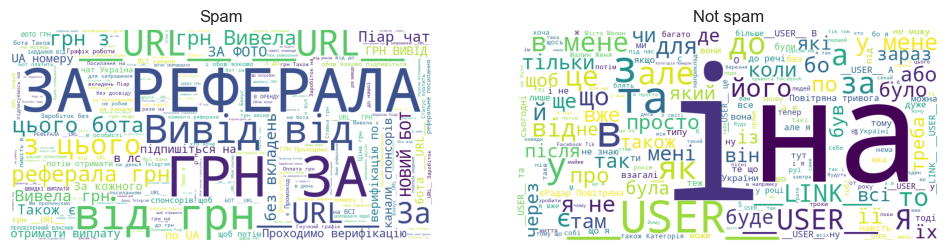

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = data[data['spam'] == 1]['text']
ham_text = data[data['spam'] == 0]['text']

spam_words = " ".join(spam_text.astype(str))
ham_words = " ".join(ham_text.astype(str))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
wc_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.imshow(wc_spam)
plt.title("Spam")
plt.axis("off")

plt.subplot(1, 2, 2)
wc_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_words)
plt.imshow(wc_ham)
plt.title("Not spam")
plt.axis("off")

plt.show()

In [23]:
# Видалення коротких слів (<2)
def filter_short_words(text):
    if not isinstance(text, str):
        return ''
    
    # прибираємо пунктуацію
    text = re.sub(r'[^\w\s]', '', text)
    
    # фільтр слів
    words = [word for word in text.split() if len(word) >= 2]
    
    return ' '.join(words)

clean_data['text'] = clean_data['text'].str.replace(r'\b__USER__\b', '', regex=True)
clean_text = clean_data['text']
# clean_data['filtered_text'] = clean_data['text'].apply(filter_short_words)

# print(clean_data['filtered_text'])